<a href="https://colab.research.google.com/github/ElNez00/ProyectoIntegrador/blob/main/Avance1_Equipo51_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EQUIPO 51

Elliot Nez Arredondo | A01796107

Luis Antonio Calderon Mata | A00278401


Fernando Guzman Briones | A01039274

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Incluye todas las librerías que consideres adecuadas:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.metrics import fbeta_score, make_scorer
from imblearn.metrics import geometric_mean_score
import statistics # import the statistics module from the standard library
from numpy import std
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate
from statistics import mean
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.metrics import roc_auc_score, average_precision_score

In [ ]:

#LUIS
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador"
os.chdir(DIR)
df = pd.read_csv('NBS_Mod_QR Orders December 2025.csv')

In [ ]:
#ELIOT
#path = '/content/drive/MyDrive/Proyecto Integrador/NBS_Mod_QR Orders December 2025(OERP (NBS)).csv'
#df = read_csv(path, header=None, encoding='latin1')

¿Hay valores faltantes en el conjunto de datos? ¿Se pueden identificar patrones de ausencia?

In [ ]:
df.head()

,Group,District,Region,Date,Month,Region Vlookup,District Vlookup,Branch Vlookup,Change Order Lookup,PROJECT,...,Unnamed: 35,Plan -2 Costs,Plan -2 CMII $,Plan -2 CMII%,MP?,CMII %,Change Order?,Product,DISTRICT,Branch Name
0,10100.00,Central West,West,12/31/2025,12.00,ALL REGIONSAll OrdersAD12,Central WestAll OrdersAD12,10100All OrdersAD12,All Orders,6741283.00,...,NaN,NaN,NaN,NaN,No,40.74%,Yes,Addwork,DMD,San Antonio
1,10414.00,Central,East,12/31/2025,12.00,ALL REGIONSAll OrdersNE12,CentralAll OrdersNE12,10414All OrdersNE12,All Orders,6741284.00,...,NaN,NaN,NaN,NaN,No,100.00%,Yes,MonoSpace 500 2-3 landing(ENA),DCE,Nashville
2,10414.00,Central,East,12/31/2025,12.00,ALL REGIONSAll OrdersNE12,CentralAll OrdersNE12,10414All OrdersNE12,All Orders,6741284.00,...,NaN,NaN,NaN,NaN,No,100.00%,Yes,MonoSpace 500 2-3 landing(ENA),DCE,Nashville
3,10100.00,Central West,West,12/31/2025,12.00,ALL REGIONSAll OrdersAD12,Central WestAll OrdersAD12,10100All OrdersAD12,All Orders,6753566.00,...,NaN,NaN,NaN,NaN,No,46.05%,Yes,Addwork,DMD,San Antonio
4,10260.00,Central,East,12/31/2025,12.00,ALL REGIONSAll OrdersTM12,CentralAll OrdersTM12,10260All OrdersTM12,All Orders,6772984.00,...,NaN,NaN,NaN,NaN,No,68.71%,Yes,Time and material,DCE,Grand Rapids


In [ ]:


faltantes = df.isnull().sum()

if faltantes.sum() == 0:
    print("No se encontraron valores faltantes en el DataFrame.")
else:
    print("Valores faltantes por columna:")
    print(faltantes[faltantes > 0])

Valores faltantes por columna:
Group                     13
District                  13
Region                    13
Date                      13
Month                     13
Region Vlookup            13
District Vlookup          13
Branch Vlookup            13
Change Order Lookup       13
PROJECT                   42
PROJECT NAME              13
ORDER CONFIRM DATE        13
 SALESPERSON              42
 RUSH ORDER DATE          13
WBS                       42
BLDG  STATE               13
EQUIP TYPE                13
PROD CODE                 13
LONGNAME                  13
CITY                      42
BRANCH                    13
KPID                      13
NETWORK                   42
SHIP DATE                 42
HO DATE                   42
 LANDING                  42
Customer Number           42
Customer                  42
 UNITS                  8258
 MV                     4705
 PLAN COSTS              184
 CMII $                   15
 CMII%                    23
 FS         

La mayoria de las columnas reflejan un faltante de 13 registros debido a que el file original, contiene subtotales y formulas en dichos renglones que no pertenecen al dataset en si, sino a algun tipo de resumen sobre la columna MV.
Existe una cantidad considerable de valores faltantes para MV (precio de venta planeado) y plan -2Rev (precio de venta final) asi como plan -2 CMII  y plan -2CMII% ( ganancia final). Revisando con el sponsor, los valores faltantes para precio de venta final corresponden a unidades que aun no cierran venta por lo que no se han determinado costos finales y por lo tanto no se puede determinar la ganancia final

La variable objetivo MV tiene muchas celdas vacias.en su mayoria corresponden a renglones donde se registran gastos adicionales de una unidad mas no representan una venta. Decidimos eliminar todos esos registros

In [ ]:
initial_rows = df.shape[0]

# Remove rows where ' MV ' is NaN
df.dropna(subset=[' MV '], inplace=True)

# Remove rows where ' MV ' is 0
df = df[df[' MV '] != 0]

final_rows = df.shape[0]

print(f"Original number of rows: {initial_rows}")
print(f"Number of rows after removing 0 and NaN in ' MV ': {final_rows}")
print(f"Number of rows removed: {initial_rows - final_rows}")

Original number of rows: 14582
Number of rows after removing 0 and NaN in ' MV ': 9877
Number of rows removed: 4705


In [ ]:
print(df[' Product '].unique())

[' Addwork ' ' MonoSpace 500 2-3 landing(ENA) ' ' Time and material '
 ' MonoSpace 500  7plus ldg (ENA) ' ' MonoSpace 500 4-6 landing(ENA) '
 ' Others ' ' KONE MonoSpace 300 2-3 landing ' ' Temp Use '
 ' MiniSpace<=4.0 m/s ' ' KONE MonoSpace 300 4-6 landing '
 ' KONE TransitMaster 220 ' ' Project Expense ' ' Monospace Special '
 ' Minispace 700 FPM ' ' TransitMaster 180 ' ' KONE TransitMaster 265 '
 ' KONE TransitMaster 210 ' ' Kone MonoSpace 4-6 ldg (US) ' nan]


El proyecto se enfocara unicamente en los productos de elevadores, elmininamos dle dataframe cualquier otro producto

In [ ]:
initial_rows = df.shape[0]

# Clean 'Product' column values by stripping spaces
df[' Product '] = df[' Product '].astype(str).str.strip()

# Define the list of allowed product names (without spaces, as the column is now stripped)
allowed_products = [
    'MonoSpace 500 2-3 landing(ENA)',
    'MonoSpace 500 4-6 landing(ENA)',
    'KONE MonoSpace 300 2-3 landing', # Adjusted based on unique values shown previously
    'KONE MonoSpace 300 4-6 landing', # Adjusted based on unique values shown previously
    'MonoSpace 500  7plus ldg (ENA)' # Adjusted for double space based on unique values shown previously
]

# Filter the DataFrame
df = df[df[' Product '].isin(allowed_products)]

final_rows = df.shape[0]

print(f"Original number of rows: {initial_rows}")
print(f"Number of rows after filtering products: {final_rows}")
print(f"Number of rows removed: {initial_rows - final_rows}")

Original number of rows: 9877
Number of rows after filtering products: 4838
Number of rows removed: 5039


In [ ]:
print(df[' Product '].unique())

['MonoSpace 500 2-3 landing(ENA)' 'MonoSpace 500  7plus ldg (ENA)'
 'MonoSpace 500 4-6 landing(ENA)' 'KONE MonoSpace 300 2-3 landing'
 'KONE MonoSpace 300 4-6 landing']


¿Cuáles son las estadísticas resumidas del conjunto de datos?

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4838 entries, 1 to 14564
Data columns (total 45 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Group                4838 non-null   float64
 1   District             4838 non-null   object 
 2   Region               4838 non-null   object 
 3   Date                 4838 non-null   object 
 4   Month                4838 non-null   float64
 5   Region Vlookup       4838 non-null   object 
 6   District Vlookup     4838 non-null   object 
 7   Branch Vlookup       4838 non-null   object 
 8   Change Order Lookup  4838 non-null   object 
 9   PROJECT              4838 non-null   float64
 10  PROJECT NAME         4838 non-null   object 
 11  ORDER CONFIRM DATE   4838 non-null   object 
 12   SALESPERSON         4838 non-null   object 
 13   RUSH ORDER DATE     4838 non-null   object 
 14  WBS                  4838 non-null   object 
 15  BLDG  STATE          4838 non-null   objec

Necesistamos convertir varias columnas a Float y otras a object

In [ ]:
columns_to_convert_to_object = ['Group', 'Month', 'PROJECT', 'BRANCH']

for col in columns_to_convert_to_object:
    if col in df.columns:
        # First, replace any empty strings with NaN to handle them consistently with other missing values.
        df[col] = df[col].replace('', pd.NA)

        # Convert to float first to handle potential string representations of floats,
        # then to int to remove decimals, and finally to string.
        # This handles cases where 'x' might be a float or a string representation of a float.
        # Handle NaN values: if NaN, convert to None temporarily, then fill with empty string before final conversion to str.
        df[col] = df[col].apply(lambda x: str(int(float(x))) if pd.notna(x) else None)
        df[col] = df[col].fillna('').astype(str)
    else:
        print(f"Column '{col}' not found in DataFrame.")

print("Data types after object conversion:")
print(df[columns_to_convert_to_object].dtypes)
display(df[columns_to_convert_to_object].head())

Data types after object conversion:
Group      object
Month      object
PROJECT    object
BRANCH     object
dtype: object


,Group,Month,PROJECT,BRANCH
1,10414,12,6741284,10414
2,10414,12,6741284,10414
9,10030,12,6772688,10030
10,10381,12,6865446,10381
17,10130,12,6867274,10130


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4838 entries, 1 to 14564
Data columns (total 45 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Group                4838 non-null   object
 1   District             4838 non-null   object
 2   Region               4838 non-null   object
 3   Date                 4838 non-null   object
 4   Month                4838 non-null   object
 5   Region Vlookup       4838 non-null   object
 6   District Vlookup     4838 non-null   object
 7   Branch Vlookup       4838 non-null   object
 8   Change Order Lookup  4838 non-null   object
 9   PROJECT              4838 non-null   object
 10  PROJECT NAME         4838 non-null   object
 11  ORDER CONFIRM DATE   4838 non-null   object
 12   SALESPERSON         4838 non-null   object
 13   RUSH ORDER DATE     4838 non-null   object
 14  WBS                  4838 non-null   object
 15  BLDG  STATE          4838 non-null   object
 16  EQUIP TYPE

In [ ]:
import numpy as np

cols_to_numeric = [
    ' UNITS ',
    ' MV ',
    ' PLAN COSTS ',
    ' CMII $ ',
    ' CMII% ',
    ' Plan -2 Rev ',
    ' Plan -2 Costs ',
    ' Plan -2 CMII $ ',
    ' Plan -2 CMII% ',
    ' CMII % '
]

for col in cols_to_numeric:
    if col in df.columns:
        # Convert to string to handle potential mixed types and ensure string methods work
        df[col] = df[col].astype(str)
        # Remove currency symbols, percentage signs, commas, and handle parentheses for negative numbers
        df[col] = df[col].str.replace('$', '', regex=False)
        df[col] = df[col].str.replace('%', '', regex=False)
        df[col] = df[col].str.replace(',', '', regex=False)
        df[col] = df[col].str.replace('(', '-', regex=False) # Convert (value) to -value
        df[col] = df[col].str.replace(')', '', regex=False)
        # Convert 'nan' string (from previous coerce or actual NaN) to actual NaN
        df[col] = df[col].replace('nan', np.nan)
        # Finally, convert to numeric, coercing any remaining errors
        df[col] = pd.to_numeric(df[col], errors='coerce')
    else:
        print(f"Column '{col}' not found in DataFrame.")

print("Data types after numeric conversion and cleaning:")
print(df[cols_to_numeric].info())
print("\nFirst 5 rows of cleaned numeric columns:")
print(df[cols_to_numeric].head())

Data types after numeric conversion and cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 4838 entries, 1 to 14564
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0    UNITS            3221 non-null   float64
 1    MV               4837 non-null   float64
 2    PLAN COSTS       4699 non-null   float64
 3    CMII $           4759 non-null   float64
 4    CMII%            4758 non-null   float64
 5    Plan -2 Rev      3220 non-null   float64
 6    Plan -2 Costs    3220 non-null   float64
 7    Plan -2 CMII $   3220 non-null   float64
 8    Plan -2 CMII%    3220 non-null   float64
 9    CMII %           4838 non-null   float64
dtypes: float64(10)
memory usage: 415.8 KB
None

First 5 rows of cleaned numeric columns:
    UNITS        MV   PLAN COSTS   CMII $   CMII%   Plan -2 Rev   \
1      NaN  -1858.00          NaN -1858.00 -100.00           NaN   
2      NaN  -1858.00          NaN -1858.00 -100.00       

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 4838 entries, 1 to 14564
Data columns (total 45 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Group                4838 non-null   object 
 1   District             4838 non-null   object 
 2   Region               4838 non-null   object 
 3   Date                 4838 non-null   object 
 4   Month                4838 non-null   object 
 5   Region Vlookup       4838 non-null   object 
 6   District Vlookup     4838 non-null   object 
 7   Branch Vlookup       4838 non-null   object 
 8   Change Order Lookup  4838 non-null   object 
 9   PROJECT              4838 non-null   object 
 10  PROJECT NAME         4838 non-null   object 
 11  ORDER CONFIRM DATE   4838 non-null   object 
 12   SALESPERSON         4838 non-null   object 
 13   RUSH ORDER DATE     4838 non-null   object 
 14  WBS                  4838 non-null   object 
 15  BLDG  STATE          4838 non-null   objec

In [ ]:
pd.set_option('display.float_format', '{:.2f}'.format)
df.describe()


,UNITS,MV,PLAN COSTS,CMII $,CMII%,Plan -2 Rev,Plan -2 Costs,Plan -2 CMII $,Plan -2 CMII%,CMII %
count,3221.00,4837.00,4699.00,4759.00,4758.00,3220.00,3220.00,3220.00,3220.00,4838.00
mean,0.97,128993.33,110725.94,21777.59,20.36,189113.00,159043.18,30069.82,15.37,31.41
std,0.24,115685.57,97837.29,21833.99,197.87,94801.69,80579.44,19077.40,6.50,194.74
min,-1.00,-431483.20,-366483.44,-212486.50,-9331.33,-431483.20,-365865.21,-65617.99,-27.23,-728.23
25%,1.00,10689.00,6240.00,5603.21,13.06,133791.98,112680.31,18765.93,12.47,13.21
50%,1.00,133694.48,114492.19,19963.81,17.41,175221.30,147001.29,26542.97,14.73,17.66
75%,1.00,200894.20,170428.21,31791.35,29.63,223985.28,189134.85,36980.90,18.38,31.55
max,1.00,806336.96,690030.93,209072.43,2420.74,807351.96,699039.31,204118.43,52.00,9331.33


¿Hay valores atípicos en el conjunto de datos?


In [ ]:
# Supongamos que analizamos la columna 'precio'
# Convertir la columna ' MV ' a tipo numérico, forzando los errores a NaN
column_to_analyze = pd.to_numeric(df[' MV '], errors='coerce')

# Separate finite values for robust IQR calculation
finite_column_to_analyze = column_to_analyze.replace([np.inf, -np.inf], np.nan).dropna()

# Check if there are enough finite values to calculate quantiles
if len(finite_column_to_analyze) > 1:
    Q1 = finite_column_to_analyze.quantile(0.25)
    Q3 = finite_column_to_analyze.quantile(0.75)
    IQR = Q3 - Q1

    # Definir límites para los atípicos basados en IQR
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Filtrar los atípicos usando el IQR para valores finitos
    iqr_outliers_indices = finite_column_to_analyze[(finite_column_to_analyze < limite_inferior) | (finite_column_to_analyze > limite_superior)].index
    iqr_outliers = df.loc[iqr_outliers_indices]
else:
    Q1, Q3, IQR, limite_inferior, limite_superior = np.nan, np.nan, np.nan, np.nan, np.nan
    iqr_outliers = pd.DataFrame() # Empty DataFrame if no finite values for IQR

# Identificar valores infinitos como atípicos (son valores extremos por definición)
infinite_outliers_indices = column_to_analyze[np.isinf(column_to_analyze)].index
infinite_outliers = df.loc[infinite_outliers_indices]

# Combinar todos los atípicos, asegurándose de no tener duplicados si un valor es tanto infinito como fuera del IQR (aunque poco probable)
all_outliers = pd.concat([iqr_outliers, infinite_outliers]).drop_duplicates()

print(f"Se encontraron {len(all_outliers)} valores atípicos")

# Optional: Print details about the limits and how many infinite values were found
print(f"Q1 (solo valores finitos): {Q1}, Q3 (solo valores finitos): {Q3}, IQR: {IQR}")
print(f"Límite Inferior: {limite_inferior}, Límite Superior: {limite_superior}")
print(f"Valores infinitos detectados como atípicos: {len(infinite_outliers)}")

Se encontraron 47 valores atípicos
Q1 (solo valores finitos): 10689.0, Q3 (solo valores finitos): 200894.2, IQR: 190205.2
Límite Inferior: -274618.80000000005, Límite Superior: 486202.00000000006
Valores infinitos detectados como atípicos: 0


¿Cuál es la cardinalidad de las variables categóricas?

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(f"Column '{col}': {df[col].nunique()} valores unicos")

Column 'Group': 61 valores unicos
Column 'District': 7 valores unicos
Column 'Region': 2 valores unicos
Column 'Date': 270 valores unicos
Column 'Month': 12 valores unicos
Column 'Region Vlookup': 60 valores unicos
Column 'District Vlookup': 413 valores unicos
Column 'Branch Vlookup': 1488 valores unicos
Column 'Change Order Lookup': 1 valores unicos
Column 'PROJECT': 2513 valores unicos
Column 'PROJECT NAME': 2492 valores unicos
Column 'ORDER CONFIRM DATE': 738 valores unicos
Column ' SALESPERSON ': 94 valores unicos
Column ' RUSH ORDER DATE ': 737 valores unicos
Column 'WBS': 4838 valores unicos
Column 'BLDG  STATE': 1 valores unicos
Column 'EQUIP TYPE': 1 valores unicos
Column 'PROD CODE': 5 valores unicos
Column 'LONGNAME': 5 valores unicos
Column 'CITY': 71 valores unicos
Column 'BRANCH': 71 valores unicos
Column 'KPID': 24 valores unicos
Column 'NETWORK': 4791 valores unicos
Column 'SHIP DATE': 923 valores unicos
Column 'HO DATE': 867 valores unicos
Column ' LANDING ': 30 valores

Grafica de barras de variables categoricas relevantes

# ¿Existen distribuciones sesgadas en el conjunto de datos? **¿Necesitamos** aplicar alguna transformación no lineal?


In [ ]:
import numpy as np

numerical_cols = df.select_dtypes(include=np.number).columns

print("Skewness for numerical columns:")
for col in numerical_cols:
    # Drop NaN values before calculating skewness to ensure accurate results
    col_data = df[col].dropna()
    if not col_data.empty:
        skewness = col_data.skew()
        skew_type = ""
        if skewness > 0.1:  # Threshold for positive skewness
            skew_type = "(Sesgo positivo)"
        elif skewness < -0.1: # Threshold for negative skewness
            skew_type = "(Sesgo negativo)"
        else:
            skew_type = "(Aproximadamente simétrico)"
        print(f"Column '{col}': {skewness:.4f} {skew_type}")
    else:
        print(f"Column '{col}': No hay datos suficientes para calcular el sesgo.")

Skewness for numerical columns:
Column ' UNITS ': -8.0112 (Sesgo negativo)
Column ' MV ': 0.6464 (Sesgo positivo)
Column ' PLAN COSTS ': 0.7119 (Sesgo positivo)
Column ' CMII $ ': 0.2346 (Sesgo positivo)
Column ' CMII% ': -44.0484 (Sesgo negativo)
Column ' Plan -2 Rev ': 0.7064 (Sesgo positivo)
Column ' Plan -2 Costs ': 0.8377 (Sesgo positivo)
Column ' Plan -2 CMII $ ': 1.5591 (Sesgo positivo)
Column ' Plan -2 CMII% ': -1.2224 (Sesgo negativo)
Column ' CMII % ': 45.4122 (Sesgo positivo)


In [ ]:
df.describe()

,UNITS,MV,PLAN COSTS,CMII $,CMII%,Plan -2 Rev,Plan -2 Costs,Plan -2 CMII $,Plan -2 CMII%,CMII %
count,3221.00,4837.00,4699.00,4759.00,4758.00,3220.00,3220.00,3220.00,3220.00,4838.00
mean,0.97,128993.33,110725.94,21777.59,20.36,189113.00,159043.18,30069.82,15.37,31.41
std,0.24,115685.57,97837.29,21833.99,197.87,94801.69,80579.44,19077.40,6.50,194.74
min,-1.00,-431483.20,-366483.44,-212486.50,-9331.33,-431483.20,-365865.21,-65617.99,-27.23,-728.23
25%,1.00,10689.00,6240.00,5603.21,13.06,133791.98,112680.31,18765.93,12.47,13.21
50%,1.00,133694.48,114492.19,19963.81,17.41,175221.30,147001.29,26542.97,14.73,17.66
75%,1.00,200894.20,170428.21,31791.35,29.63,223985.28,189134.85,36980.90,18.38,31.55
max,1.00,806336.96,690030.93,209072.43,2420.74,807351.96,699039.31,204118.43,52.00,9331.33


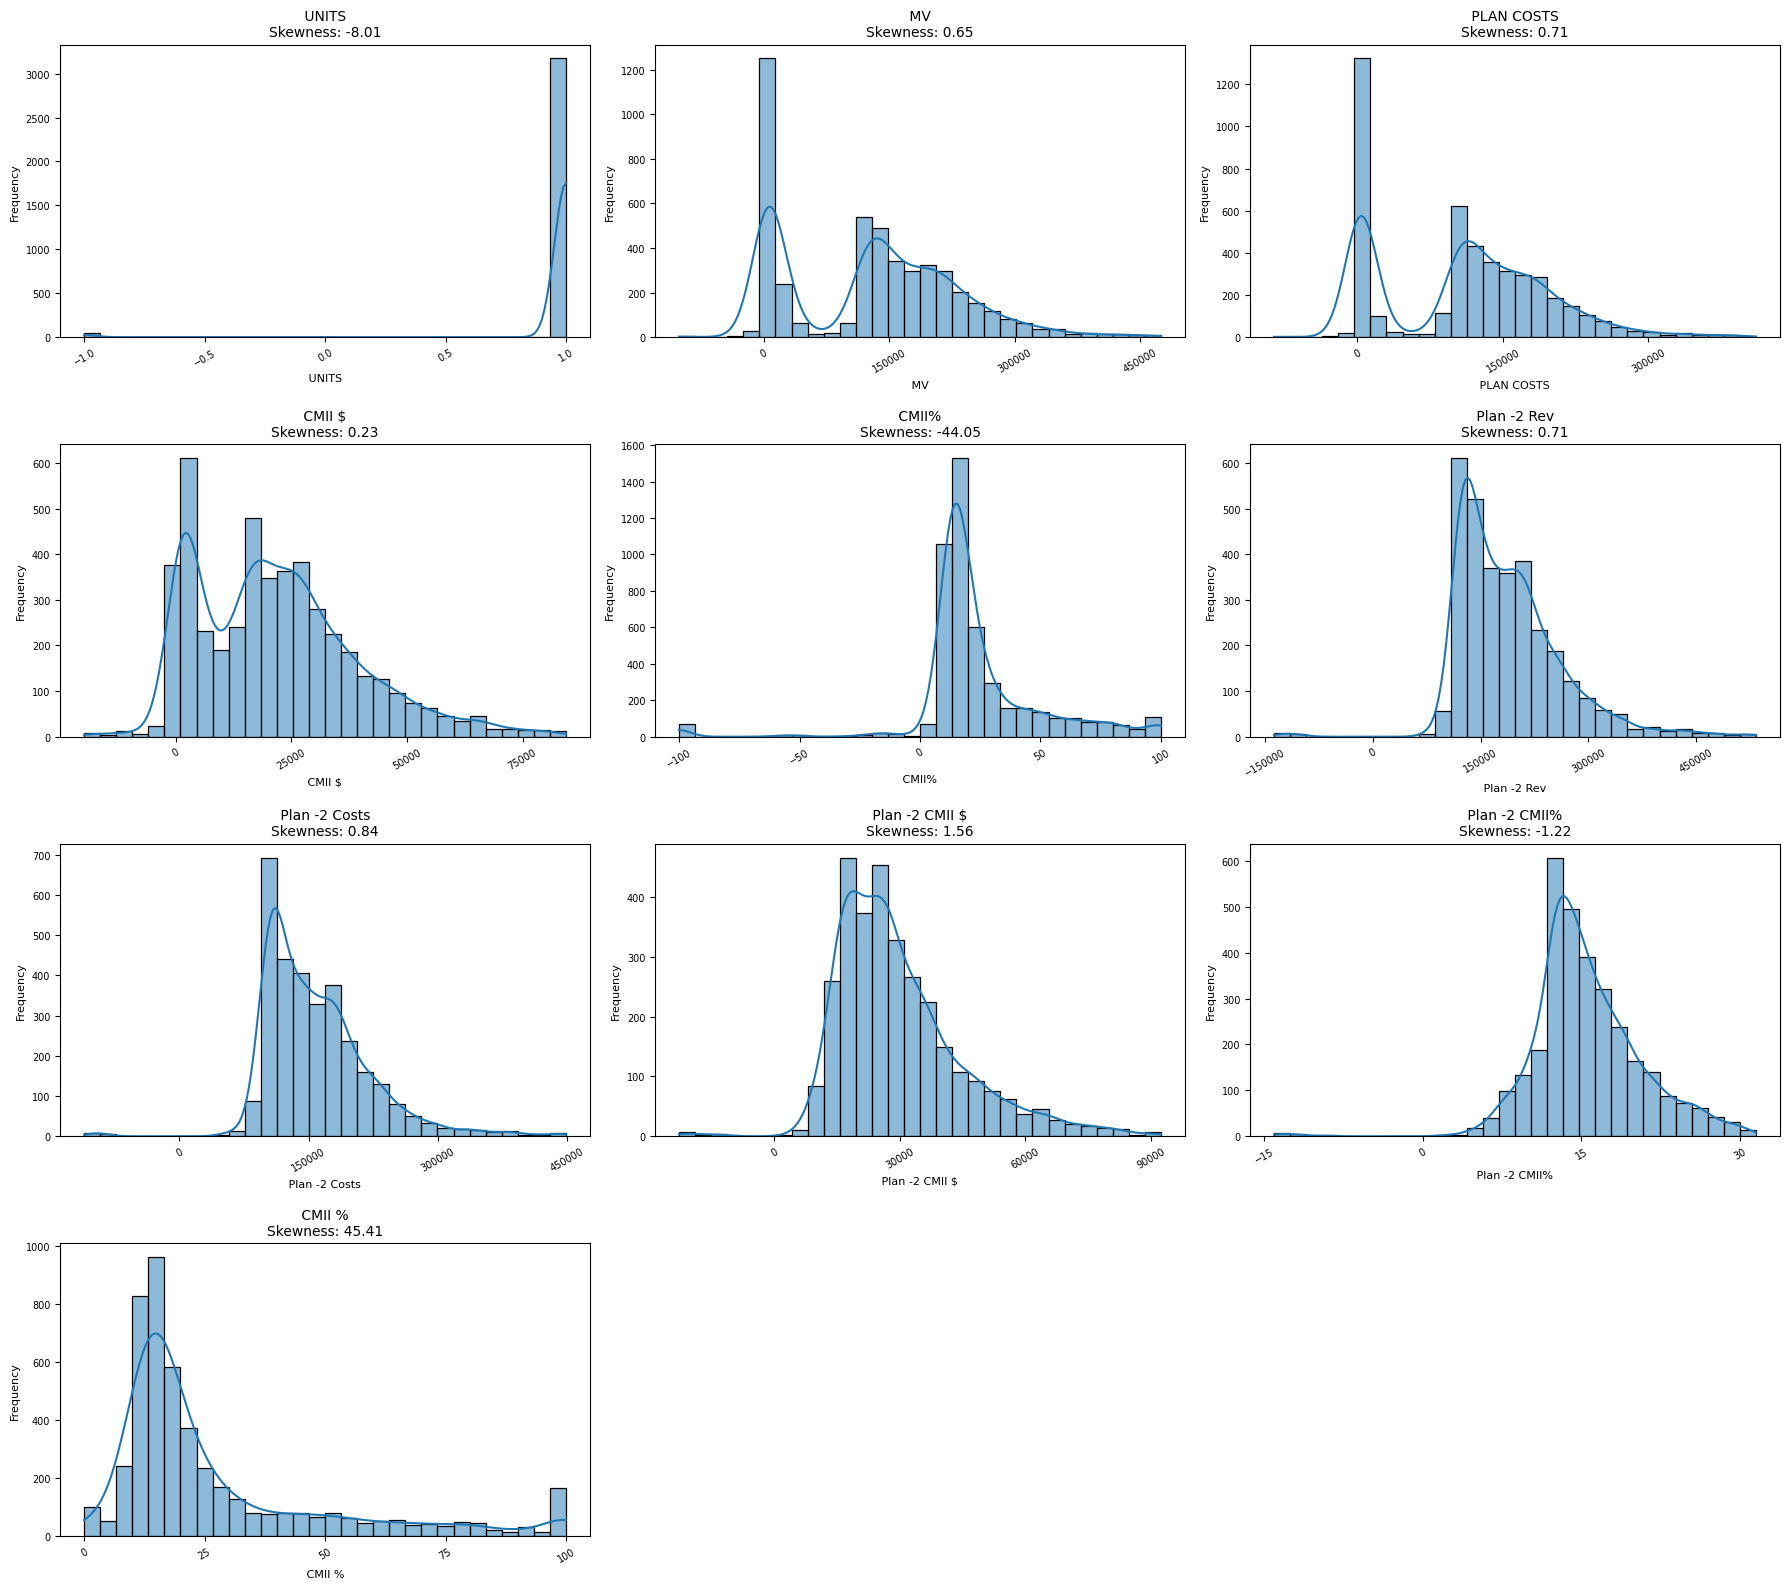

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import MaxNLocator

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import MaxNLocator

# Select numeric columns
numerical_cols = df.select_dtypes(include=np.number).columns

# Grid size
rows = 4
cols = 3

# Create figure
fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))

# Flatten axes for iteration
axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    if i < len(axes):

        # Remove NaN values
        data = df[col].dropna()

        # Optional: remove extreme outliers ONLY for visualization
        lower = data.quantile(0.01)
        upper = data.quantile(0.99)

        data_filtered = data[(data >= lower) & (data <= upper)]

        # Plot histogram + KDE
        sns.histplot(
            data_filtered,
            kde=True,
            bins=30,
            ax=axes[i]
        )

        # Calculate skewness
        skewness = data.skew()

        # Titles
        axes[i].set_title(
            f'{col}\nSkewness: {skewness:.2f}',
            fontsize=10
        )

        # Labels
        axes[i].set_xlabel(col, fontsize=8)
        axes[i].set_ylabel('Frequency', fontsize=8)

        # Improve x-axis readability
        axes[i].xaxis.set_major_locator(MaxNLocator(5))

        # Remove scientific notation
        axes[i].ticklabel_format(style='plain', axis='x')

        # Rotate labels slightly
        axes[i].tick_params(axis='x', labelsize=7, rotation=30)
        axes[i].tick_params(axis='y', labelsize=7)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust spacing
plt.tight_layout()

# Show plot
plt.show()

In [ ]:
#utilizando robustscaler ya que practicametne todos las columnas tienen outliers
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
df[cols_to_numeric] = scaler.fit_transform(df[cols_to_numeric])

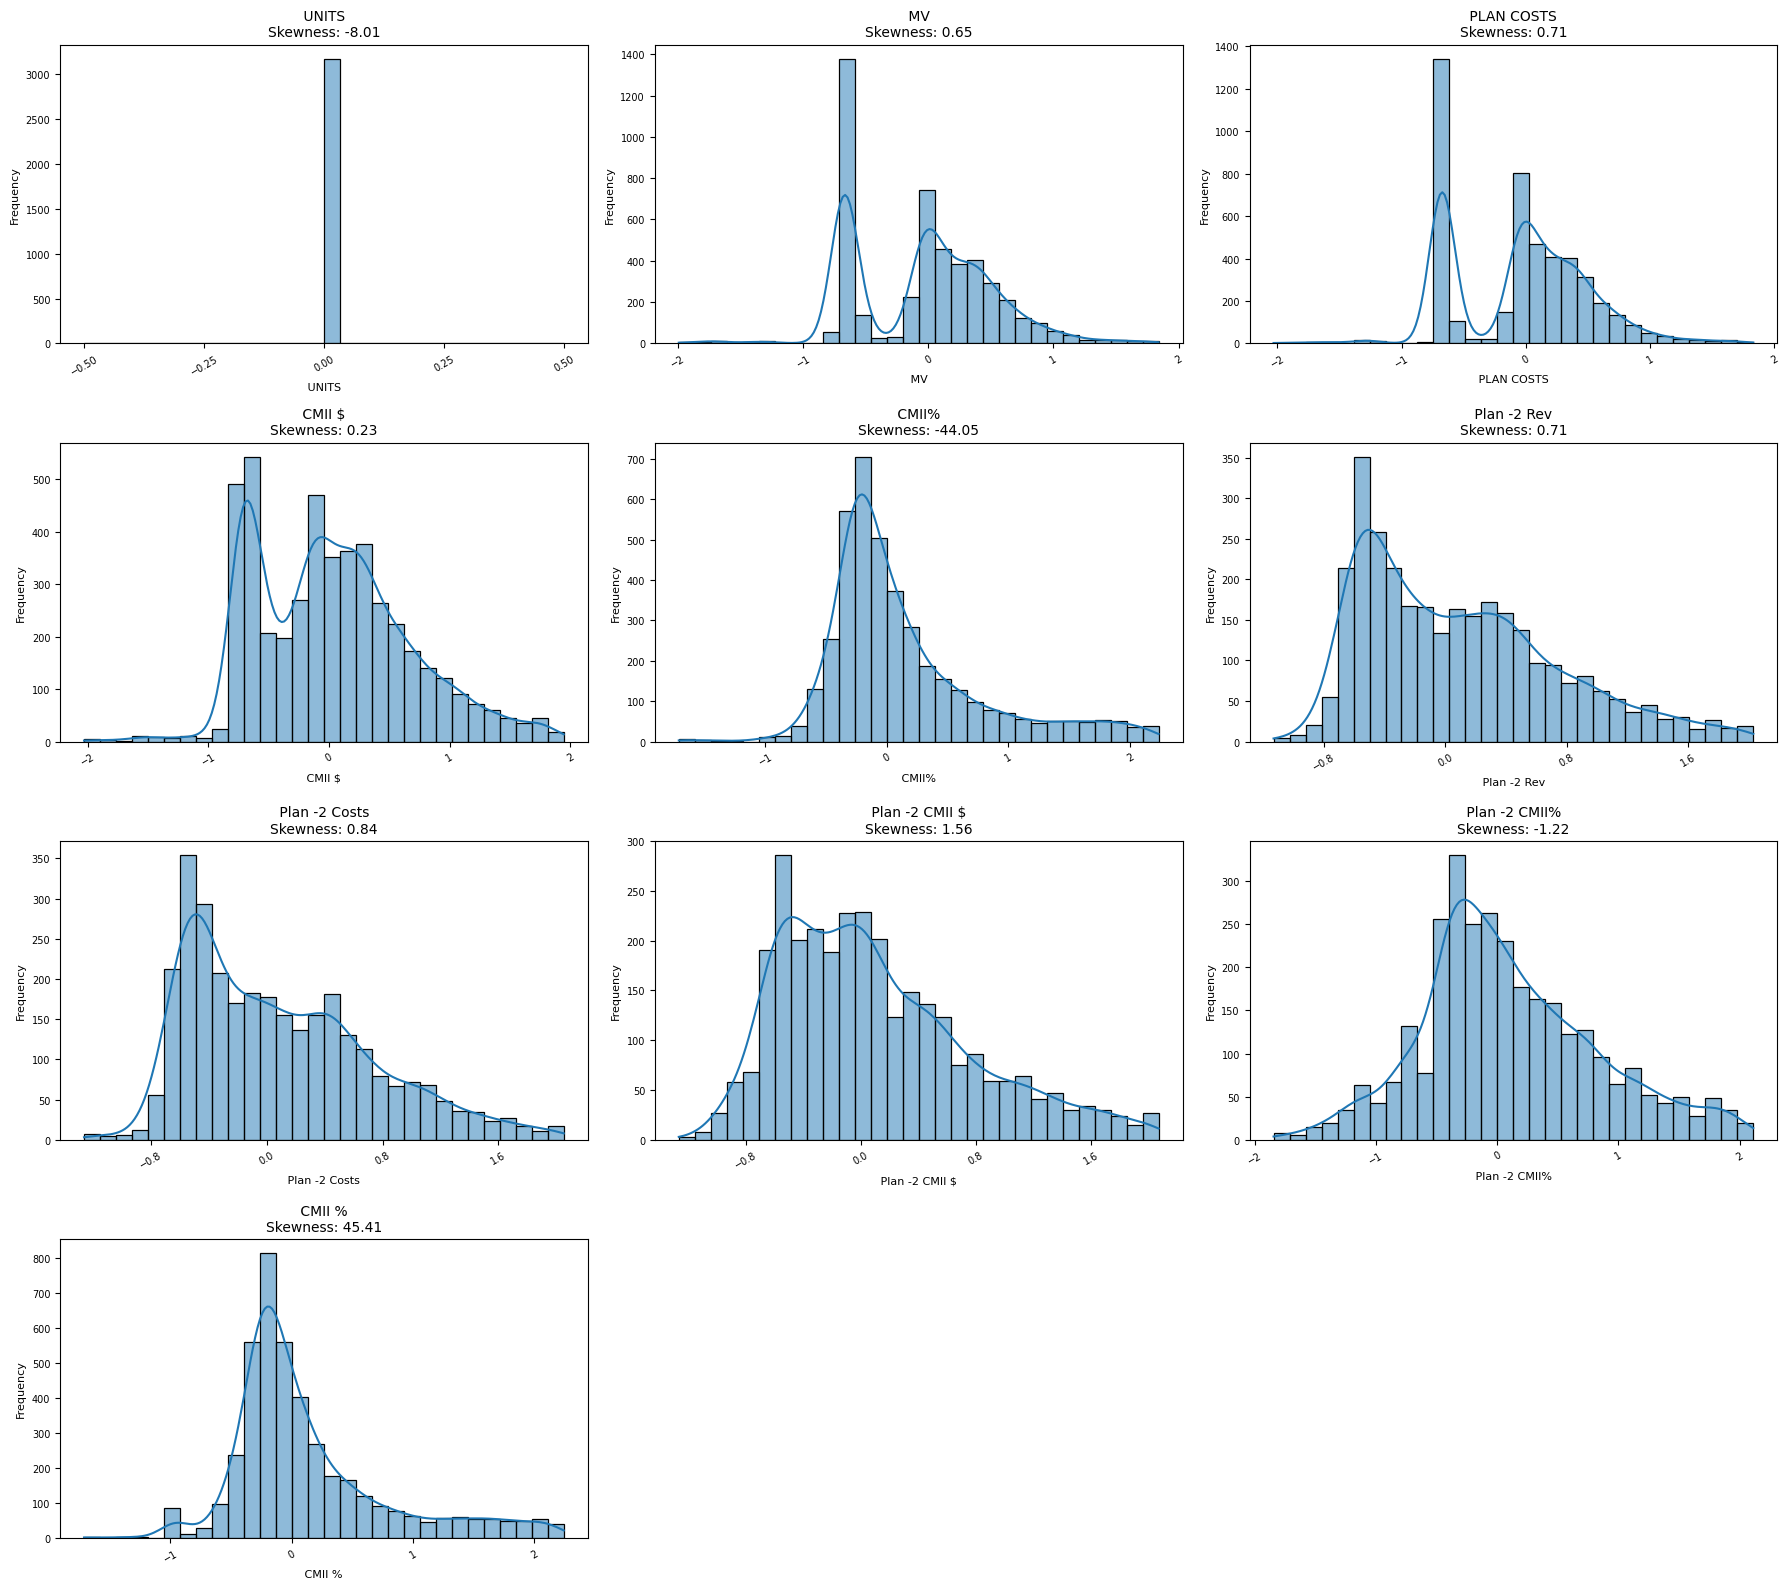

In [ ]:
#nuevas graficas despues de transformacion con RObust SCaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import MaxNLocator

# Select the numerical columns that were scaled
numerical_cols_scaled = cols_to_numeric

# Grid size - dynamically determine based on number of columns
num_cols_to_plot = len(numerical_cols_scaled)
rows = math.ceil(num_cols_to_plot / 3) # 3 columns per row
cols = 3

# Create figure
fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))

# Flatten axes for iteration
axes = axes.flatten()

for i, col in enumerate(numerical_cols_scaled):
    if i < len(axes):
        # Remove NaN values
        data = df[col].dropna()

        # Optional: remove extreme outliers ONLY for visualization
        # Using IQR to find outliers for visualization even after RobustScaler
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        data_filtered = data[(data >= lower_bound) & (data <= upper_bound)]

        # Plot histogram + KDE
        sns.histplot(
            data_filtered,
            kde=True,
            bins=30,
            ax=axes[i]
        )

        # Calculate skewness
        skewness = data.skew()

        # Titles
        axes[i].set_title(
            f'{col}\nSkewness: {skewness:.2f}',
            fontsize=10
        )

        # Labels
        axes[i].set_xlabel(col, fontsize=8)
        axes[i].set_ylabel('Frequency', fontsize=8)

        # Improve x-axis readability
        axes[i].xaxis.set_major_locator(MaxNLocator(5))

        # Remove scientific notation
        axes[i].ticklabel_format(style='plain', axis='x')

        # Rotate labels slightly
        axes[i].tick_params(axis='x', labelsize=7, rotation=30)
        axes[i].tick_params(axis='y', labelsize=7)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust spacing
plt.tight_layout()

# Show plot
plt.show()

Podemos observar que algunas graficas son bimodales por lo que tenemos que investigar mas a fondo si tenemos dos distribuciones diferentes

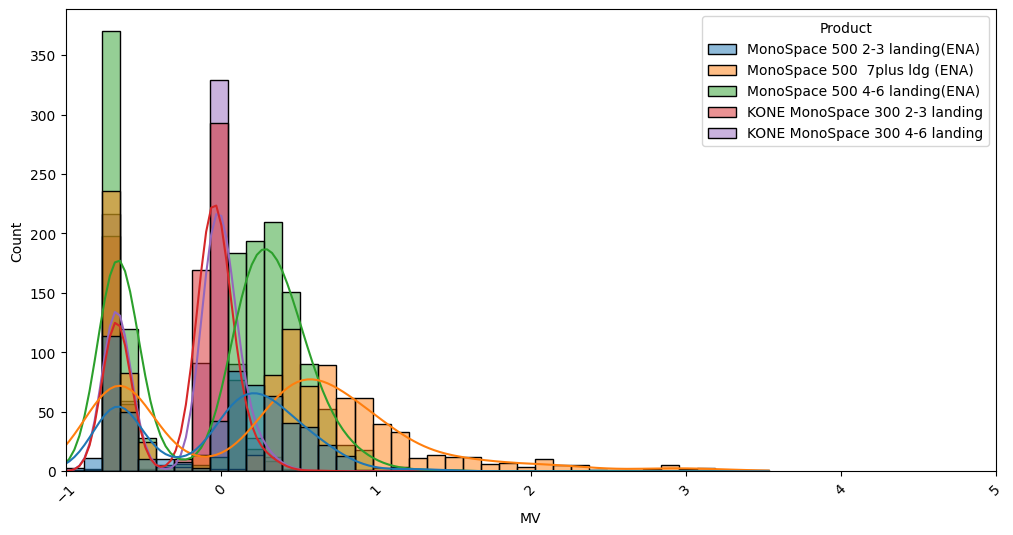

In [ ]:
# Clean column names
df.columns = df.columns.str.strip()

# Create figure
plt.figure(figsize=(12,6))

# Plot
sns.histplot(
    data=df,
    x="MV",
    hue="Product",
    kde=True
)

# Expand x-axis
plt.xlim(-1, 5)   # adjust range as needed

# Improve readability
plt.xticks(rotation=45)

plt.show()

De acuerdo a la grafica superior, podemos ver claramente como productos diferentes (M300 v.s M500) generan picos independientes en MV y en otras variables. Es necesario determinar si hacemos un analisis independiente de cada producto o nos enfocamos en el de mayor volumen

¿Se identifican tendencias temporales? (En caso de que el conjunto incluya una dimensión de tiempo).

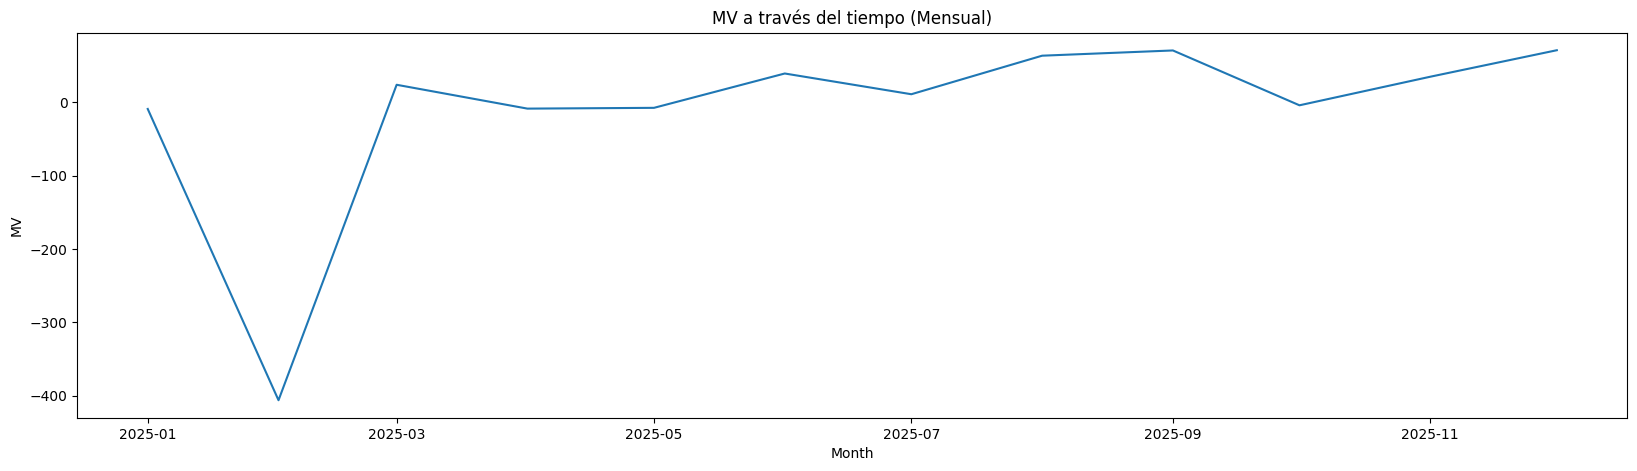

In [ ]:
# Convert to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Create monthly period
df["Month"] = df["Date"].dt.to_period("M")

# Aggregate MV by month
monthly_mv = df.groupby("Month")["MV"].sum().reset_index()

# Convert Month back to datetime for plotting
monthly_mv["Month"] = monthly_mv["Month"].dt.to_timestamp()

# Plot
plt.figure(figsize=(20,5))
sns.lineplot(data=monthly_mv, x="Month", y="MV")

plt.title("MV a través del tiempo (Mensual)")
plt.xlabel("Month")
plt.ylabel("MV")
plt.show()

Se puede apreciar un comportamiento anormal especificamente en febrero, es posible que de deba a un conjunto de outliers ya que los demas meses el MV se mantiene relativamente constante

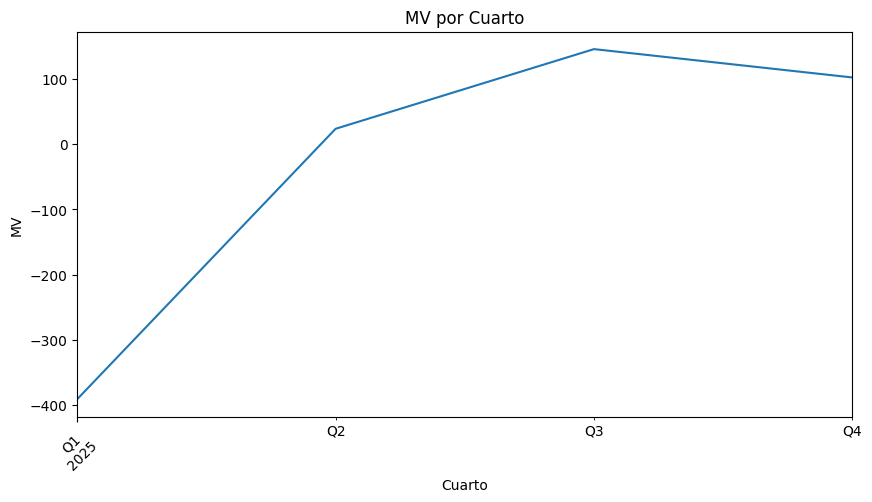

In [ ]:
quarterly_mv.plot(figsize=(10,5))
plt.title("MV por Cuarto")
plt.xlabel("Cuarto")
plt.ylabel("MV")
plt.xticks(rotation=45)
plt.show()

De acuerdo a la relacion cuarto v.s precio de venta, hay una tendencia extrania durante Q1 donde el precio de venta es el mas bajo v.s Q3 que reporta el mas alto

Hay correlación entre las variables dependientes e independientes?

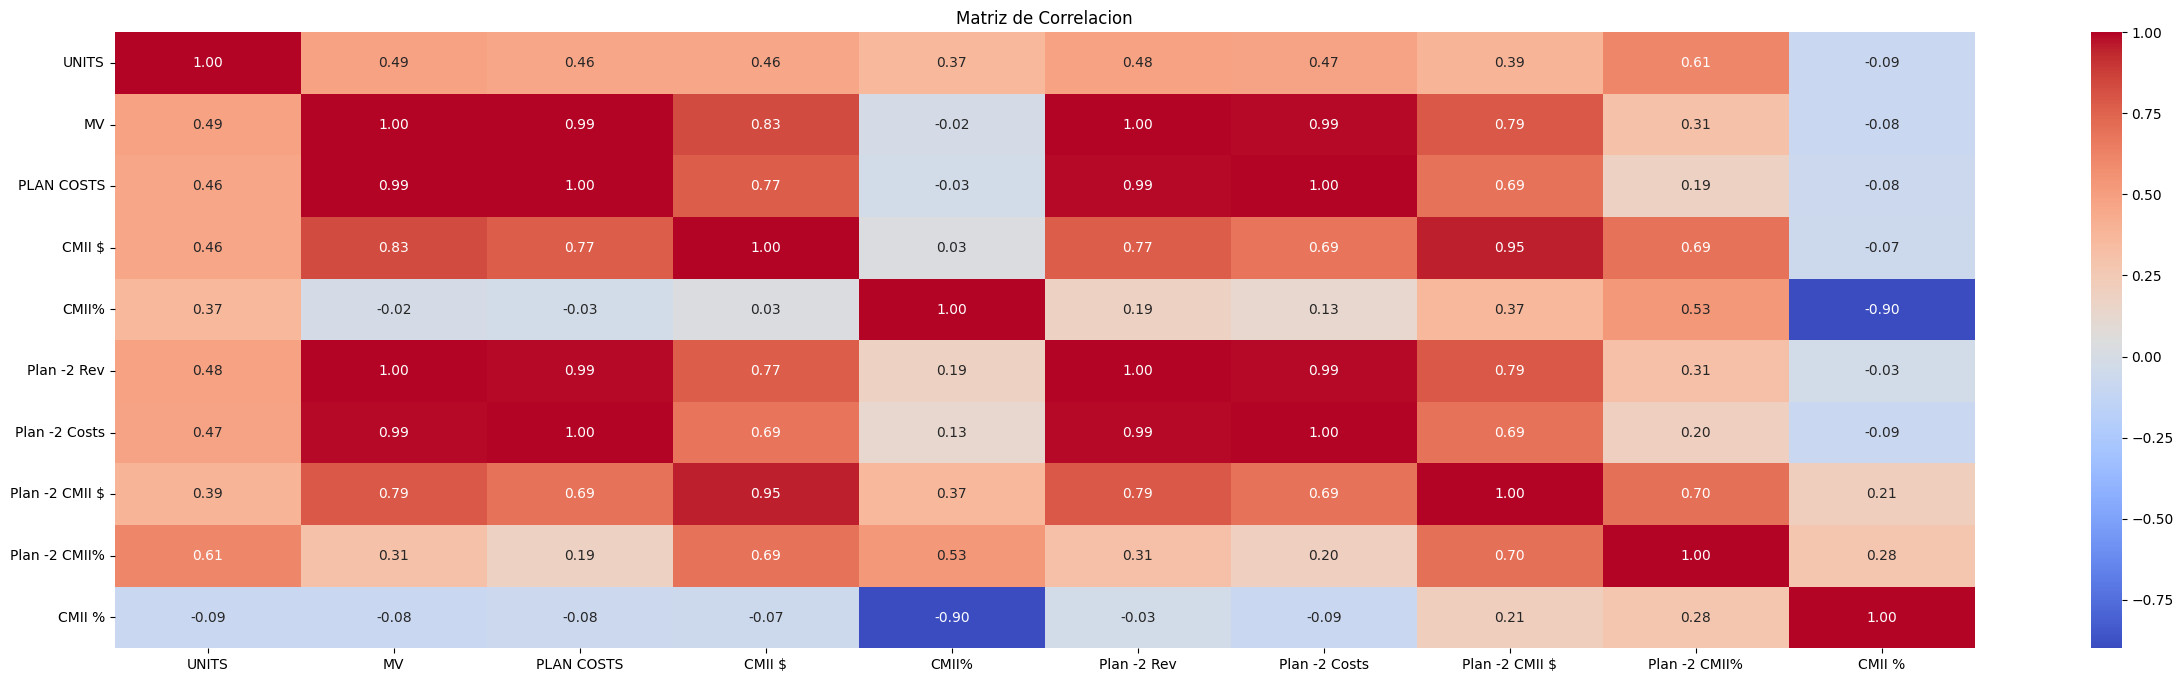

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

numeric_df = df.select_dtypes(include=[np.number]).copy()
numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)
numeric_df = numeric_df.dropna(axis=1, how='all')
corr_matrix = numeric_df.corr()
plt.figure(figsize=(30, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlacion")
plt.show()

definimos lospares de caracteristics con correlacion perfecta, alta baja y nula

In [ ]:
perfect_correlated_pairs = []
highly_correlated_pairs = []
low_correlated_pairs = []
no_correlated_pairs = []


for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        correlation_value = corr_matrix.iloc[i, j]
        abs_corr_val = abs(correlation_value)

        if 0.9 <= abs_corr_val <= 1.0:
            perfect_correlated_pairs.append((col1, col2, correlation_value))
        elif 0.7 <= abs_corr_val < 0.9:
            highly_correlated_pairs.append((col1, col2, correlation_value))
        elif 0.1 <= abs_corr_val <= 0.3:
            low_correlated_pairs.append((col1, col2, correlation_value))
        elif 0.0 <= abs_corr_val < 0.1:
            no_correlated_pairs.append((col1, col2, correlation_value))


if perfect_correlated_pairs:
    print("Par de caracteristicas con correlacion perfecta (0.9 a 1.0):")
    for col1, col2, corr_val in perfect_correlated_pairs:
        print(f"- ('{col1}', '{col2}'): {corr_val:.2f}")
else:
    print("No se encontraron pares de caracteristicas con correlacion perfecta.")

print("\n")

if highly_correlated_pairs:
    print("Par de caracteristicas con correlacion alta (0.7 a 0.9):")
    for col1, col2, corr_val in highly_correlated_pairs:
        print(f"- ('{col1}', '{col2}'): {corr_val:.2f}")
else:
    print("No se encontraron pares de caracteristicas con correlacion alta (0.7 a 0.9).")

print("\n")

if low_correlated_pairs:
    print("Par de caracteristicas con correlacion baja (0.1 a 0.3):")
    for col1, col2, corr_val in low_correlated_pairs:
        print(f"- ('{col1}', '{col2}'): {corr_val:.2f}")
else:
    print("No se encontraron pares de caracteristicas con correlacion baja (0.1 a 0.3).")

print("\n")

if no_correlated_pairs:
    print("Par de caracteristicas sin correlacion (0.0 a 0.1):")
    for col1, col2, corr_val in no_correlated_pairs:
        print(f"- ('{col1}', '{col2}'): {corr_val:.2f}")
else:
    print("No se encontraron pares de caracteristicas sin correlacion (0.0 a 0.1).")

Par de caracteristicas con correlacion perfecta (0.9 a 1.0):
- ('MV', 'PLAN COSTS'): 0.99
- ('MV', 'Plan -2 Rev'): 1.00
- ('MV', 'Plan -2 Costs'): 0.99
- ('PLAN COSTS', 'Plan -2 Rev'): 0.99
- ('PLAN COSTS', 'Plan -2 Costs'): 1.00
- ('CMII $', 'Plan -2 CMII $'): 0.95
- ('Plan -2 Rev', 'Plan -2 Costs'): 0.99


Par de caracteristicas con correlacion alta (0.7 a 0.9):
- ('MV', 'CMII $'): 0.83
- ('MV', 'Plan -2 CMII $'): 0.79
- ('PLAN COSTS', 'CMII $'): 0.77
- ('CMII $', 'Plan -2 Rev'): 0.77
- ('CMII%', 'CMII %'): -0.90
- ('Plan -2 Rev', 'Plan -2 CMII $'): 0.79


Par de caracteristicas con correlacion baja (0.1 a 0.3):
- ('PLAN COSTS', 'Plan -2 CMII%'): 0.19
- ('CMII%', 'Plan -2 Rev'): 0.19
- ('CMII%', 'Plan -2 Costs'): 0.13
- ('Plan -2 Costs', 'Plan -2 CMII%'): 0.20
- ('Plan -2 CMII $', 'CMII %'): 0.21
- ('Plan -2 CMII%', 'CMII %'): 0.28


Par de caracteristicas sin correlacion (0.0 a 0.1):
- ('UNITS', 'CMII %'): -0.09
- ('MV', 'CMII%'): -0.02
- ('MV', 'CMII %'): -0.08
- ('PLAN COSTS', 'CM

¿Cómo se distribuyen los datos en función de diferentes categorías? (análisis bivariado)


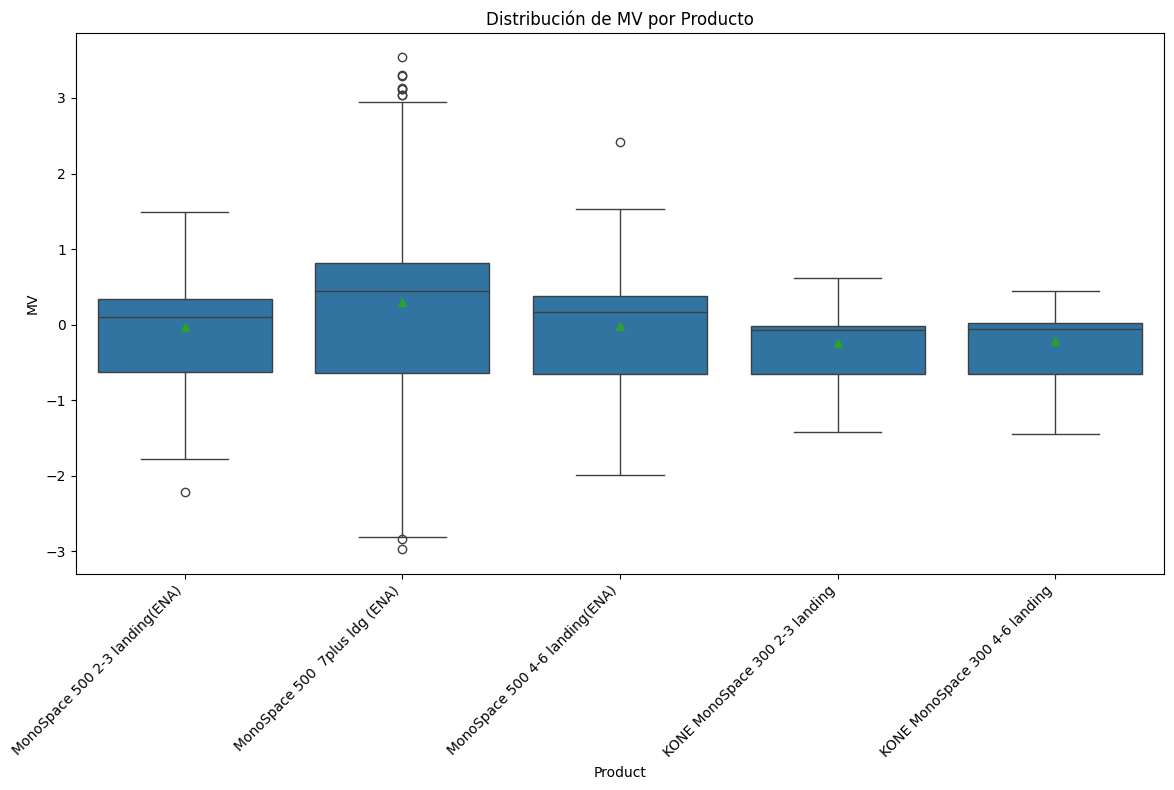

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.boxplot(x='Product', y='MV', data=df, showmeans = True)
plt.title('Distribución de MV por Producto')
plt.xlabel('Product')
plt.ylabel('MV')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

En el caso de precio de venta por producto podemos notar mayor variabilidad en minimos y maximos asi cmo la cantidad de outliers para el caso de M500 7plus.
M300 en sus dos coniguraciones es relativamente uniforme

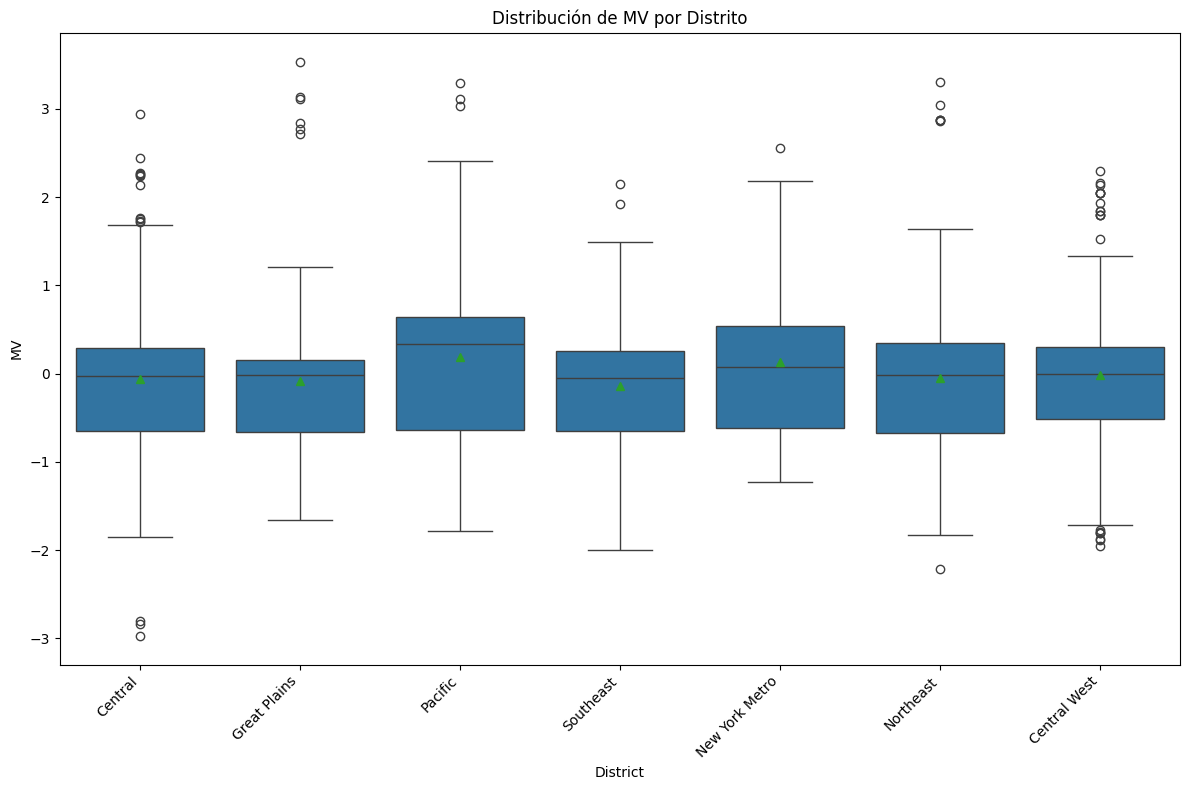

In [ ]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='District', y='MV', data=df, showmeans = True)
plt.title('Distribución de MV por Distrito')
plt.xlabel('District')
plt.ylabel('MV')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

La relacion precio de venta vs distrito es relativamente similar con algunas regiciones como pacifico y New york que muestran un mayor spread en los cuartiles 1 y 3.

¿Se deberían normalizar las imágenes para visualizarlas mejor?

Este no es un proyecto de imágenes por lo cual esta pregunta no aplica

¿Hay desequilibrio en las clases de la variable objetivo?

Este no es un proyecto de clasificacion por lo cual esta pregunta no aplica
